# Week 2 - 9/14/2026: Dataset Exploration

Goal: get familiar with the raw dataset before any cleaning or modeling.

This notebook covers:
- Loading the raw data
- Variable definitions and data types
- General dataset stats (row/column counts, missing values, etc.)

## Setup

We used `pathlib` to build the path to the raw data folder relative to this notebook.
so the notebook works for every team member regardless of where they
cloned the repo on their own machine.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
      
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_FILE = RAW_DATA_DIR / "big_startup_secsees_dataset.csv"

## Load the dataset

In [63]:
df = pd.read_csv(DATA_FILE)

df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/sentic-technologies-inc,Sentic Technologies Inc,http://www.sentictechnologies.com,Information Technology|Internet|SaaS|Search Ma...,1,operating,USA,IL,Chicago,Chicago,1,2/1/2014,11/12/2015,11/12/2015
1,/organization/step-to-the-future,Step to the future,https://www.indiegogo.com/projects/step-to-the...,Flash Storage|Service Providers|Startups,1,operating,RUS,48,Moscow,Moscow,1,3/7/2015,3/7/2015,3/7/2015
2,/organization/krad-radio,Soundctl,http://soundctl.com,Audio|Video Streaming,2,operating,USA,CA,SF Bay Area,Mountain View,1,7/1/2015,9/23/2015,9/23/2015
3,/organization/synergia-pharma,Synergia Pharma,http://www.synergiapharma.com/,Pharmaceuticals,2,closed,USA,CA,SF Bay Area,San Francisco,1,NaN,2/11/2003,2/11/2003
4,/organization/moomix-gaming,Moomix Gaming,NaN,Media|News,5,operating,CAN,NS,NS - Other,Eastern Passage,1,1/26/2015,1/26/2015,1/26/2015


## General dataset stats

Row count, column count, and column names.

In [64]:
n_rows, n_cols = df.shape

print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
print(f"Column names:{list(df.columns)}")

Number of rows: 66367
Number of columns: 14
Column names:['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at']


## Variable definitions and data types

For each column: its data type, number of missing values, and number of unique values.
This gives a quick sense of which variables are numeric, categorical, or dates,
and how complete each one is.

In [65]:
variable_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

variable_summary

,dtype,missing_values,missing_pct,unique_values
permalink,object,0,0.00,66367
name,object,1,0.00,66101
homepage_url,object,5058,7.62,61190
category_list,object,3148,4.74,27295
funding_total_usd,object,0,0.00,18896
status,object,0,0.00,4
country_code,object,6958,10.48,137
state_code,object,8547,12.88,311
region,object,8030,12.10,1092
city,object,8028,12.10,5111


## Summary statistics for numeric columns

In [66]:
df.describe()

,funding_rounds
count,"66,367.00"
mean,1.73
std,1.36
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,19.00


## Visualizing missing data

A simple bar chart of missing value counts per column, using only matplotlib
so it stays easy to read and modify.

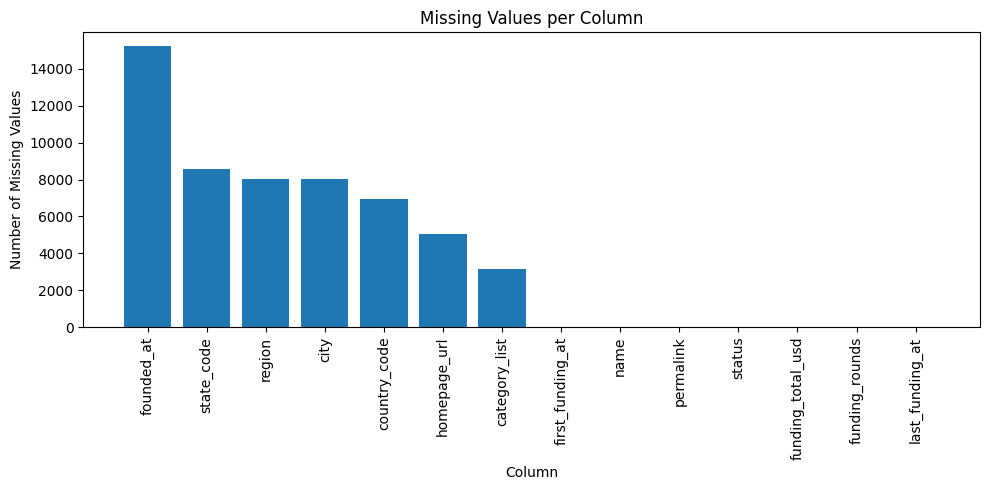

In [67]:
missing_counts = df.isnull().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missing_counts.index, missing_counts.values)

ax.set_title("Missing Values per Column")
ax.set_xlabel("Column")
ax.set_ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Target Variable

Our target variable is `status`, which categorizes each startup's outcome as one of four values: operating, acquired, closed, or ipo (i.e., went public).

We chose `status` as the target because our project's goal is to predict startup outcomes beyond simply looking at total funding raised. A total-funding-only view treats two startups that raised the same amount over very different timelines as equivalent, even though the path each company took to reach that funding level tells a very different story. By using `status` as the outcome we're predicting, we can incorporate funding velocity and timing patterns (how quickly rounds occurred relative to founding and to each other) as predictors, since those signals say more about a company's trajectory than the funding total alone.

In [68]:
# Count and percentage breakdown of each status category
status_counts = df['status'].value_counts()
status_pct = (df['status'].value_counts(normalize=True) * 100).round(2)

pd.DataFrame({'count': status_counts, 'percent': status_pct})

,count,percent
status,,
operating,53033,79.91
closed,6238,9.40
acquired,5549,8.36
ipo,1547,2.33


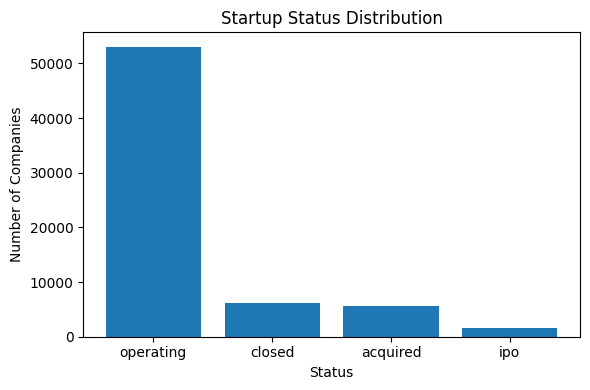

In [69]:
# Bar chart showing the distributionof startups across each status category
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(status_counts.index, status_counts.values)

ax.set_title("Startup Status Distribution")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Companies")
plt.tight_layout()
plt.show()

# Week 3 - 9/21/2026: Exploratory Data Analysis

Here we clean the fields that need it and look for patterns tied to `status`, since that's what we're
ultimately trying to predict.

### Cleaning funding_total_usd

This column is stored as text, and uses dashes as a replacement value for nulls instead of
a blank cell, so we need to explicitly convert it to numeric before we can use it.

In [70]:
df['funding_total_usd_clean'] = pd.to_numeric(
    df['funding_total_usd'].replace('-', np.nan), errors='coerce'
)

n_missing_dash = (df['funding_total_usd'] == '-').sum()
pct_missing_dash = (n_missing_dash / len(df) * 100).round(2)
print(f"Rows using '-': {n_missing_dash} ({pct_missing_dash}% of all rows)")

desc = df['funding_total_usd_clean'].describe()
pd.options.display.float_format = '{:,.2f}'.format

print(f"\nSummary stats for funding_total_usd_clean (excluding the {n_missing_dash} rows marked '-'):")
print(desc)

Rows using '-': 12785 (19.26% of all rows)

Summary stats for funding_total_usd_clean (excluding the 12785 rows marked '-'):
count           53,582.00
mean        18,478,946.10
std        188,015,010.60
min                  1.00
25%            335,810.25
50%          2,000,000.00
75%         10,000,000.00
max     30,079,503,000.00
Name: funding_total_usd_clean, dtype: float64


### Parsing dates and deriving funding-velocity features

We parsed founded_at, first_funding_at, and last_funding_at into real dates, then derived
two features that relate directly to our funding-velocity hypothesis from Week 1:

- days_to_first_funding: how long after founding a startup got its first funding
- funding_span_days: how long the startup was actively raising, from first to last round

In [71]:
for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
    df[col + '_dt'] = pd.to_datetime(df[col], errors='coerce')

df['days_to_first_funding'] = (df['first_funding_at_dt'] - df['founded_at_dt']).dt.days
df['funding_span_days'] = (df['last_funding_at_dt'] - df['first_funding_at_dt']).dt.days
df['founded_year'] = df['founded_at_dt'].dt.year

print("Date parse failures (non-null in raw column, null after parsing):")
for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
    n_failed = df[col].notna().sum() - df[col + '_dt'].notna().sum()
    print(f"  {col}: {n_failed}")

print("\nExamples of values that failed to parse:")
for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
    failed_mask = df[col].notna() & df[col + '_dt'].isna()
    n_failed = failed_mask.sum()
    if n_failed > 0:
        print(f"\n{col} ({n_failed} failed):")
        print(df.loc[failed_mask, col].head(10))

df[['days_to_first_funding', 'funding_span_days']].describe()

Date parse failures (non-null in raw column, null after parsing):
  founded_at: 108
  first_funding_at: 3
  last_funding_at: 0

Examples of values that failed to parse:

founded_at (108 failed):
408      1881-05-01
2134     1015-01-30
5993     1898-01-01
10177    1862-01-01
10882    1888-01-01
11948    1869-01-01
15371    1871-01-01
16664    1826-01-01
18187    1897-01-01
18971    1880-01-01
Name: founded_at, dtype: object

first_funding_at (3 failed):
47326    1014-03-01
47930    1532-06-26
57828    1201-11-23
Name: first_funding_at, dtype: object


,days_to_first_funding,funding_span_days
count,"51,015.00","66,340.00"
mean,"1,263.00",342.23
std,"2,579.52",710.36
min,"-9,465.00",0.00
25%,143.00,0.00
50%,514.00,0.00
75%,"1,359.00",416.00
max,"41,159.00","36,994.00"


### Checking for date data-quality issues

If funding happened before a company's founding date, or a company was "founded" in an
impossible year, we will most likely remove it since it is a bad source of data.

In [72]:
n_negative_funding_gap = (df['days_to_first_funding'] < 0).sum()
print(f"Rows with funding recorded before founding date: {n_negative_funding_gap}")

print(f"\nfounded_year range: {df['founded_year'].min():.0f} - {df['founded_year'].max():.0f}")
print("\nSuspicious founded_year values (before 1950 or after 2016):")
print(df.loc[
    (df['founded_year'] < 1950) | (df['founded_year'] > 2016),
    ['name', 'founded_at', 'founded_year']
])

Rows with funding recorded before founding date: 3761

founded_year range: 1901 - 2016

Suspicious founded_year values (before 1950 or after 2016):
                             name founded_at  founded_year
58        Hollywood Vision Center  6/12/1919      1,919.00
2436                         ODEC   1/1/1948      1,948.00
4375                   FastHealth  3/22/1921      1,921.00
7339                Since1910.com   1/1/1910      1,910.00
9170   Purdue Research Foundation   1/1/1930      1,930.00
...                           ...        ...           ...
63332                  SFC Koenig   1/1/1927      1,927.00
63693                  Smit Ovens   1/1/1936      1,936.00
64973                        TOUS   1/1/1920      1,920.00
65850                    Weetabix   1/1/1932      1,932.00
65878             Wer Liefert Was   1/1/1932      1,932.00

[127 rows x 3 columns]


All of the suspicious `founded_year` values turn out to be one kind of issue, either the organization listed in the dataset is a real, hundred year old business or there are bad data issues with the year.:

- founded_year < 1950 (127 rows): names like Hollywood Vision Center, Purdue Research
  Foundation, Siena College, Harvard University — these are real, well-known, long-established
  organizations. These legacy/large organizations that show up in this
  "startup" dataset (e.g. universities, hospitals, foundations, century-old manufacturers) are a scope problem that we have to deal with. The chart below shows in more detail what is going on. 

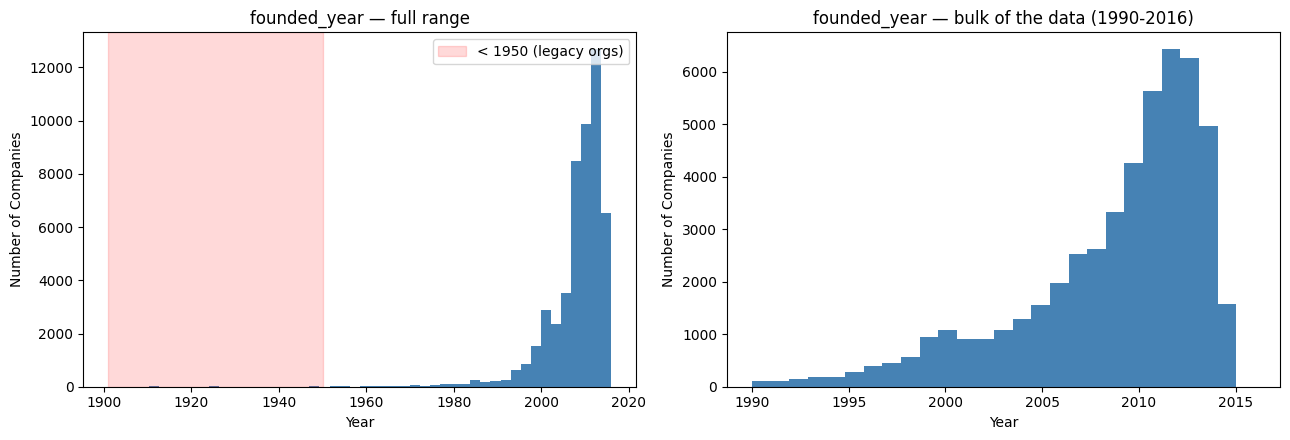

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: full distribution, linear scale, with the legacy-org tail highlighted
axes[0].hist(df['founded_year'].dropna(), bins=50, color='steelblue')
axes[0].axvspan(df['founded_year'].min(), 1950, color='red', alpha=0.15, label='< 1950 (legacy orgs)')
axes[0].set_title("founded_year — full range")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Companies")
axes[0].legend()

# Right: zoomed into the bulk, 1990-2016, for reference
recent = df.loc[df['founded_year'].between(1990, 2016), 'founded_year']
axes[1].hist(recent, bins=27, color='steelblue')
axes[1].set_title("founded_year — bulk of the data (1990-2016)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Companies")

plt.tight_layout()
plt.show()

In [81]:
legacy_orgs = df.loc[df['founded_year'] < 1950, ['name', 'founded_at', 'founded_year']]

print(f"\nLegacy orgs (founded_year < 1950): {len(legacy_orgs)} rows")
legacy_orgs.head(10)


Legacy orgs (founded_year < 1950): 127 rows


,name,founded_at,founded_year
58,Hollywood Vision Center,6/12/1919,"1,919.00"
2436,ODEC,1/1/1948,"1,948.00"
4375,FastHealth,3/22/1921,"1,921.00"
7339,Since1910.com,1/1/1910,"1,910.00"
9170,Purdue Research Foundation,1/1/1930,"1,930.00"
9213,Siena College,1/1/1937,"1,937.00"
9340,Whittier Street Health Center,1/1/1933,"1,933.00"
9384,Poudre Valley Health System,1/1/1925,"1,925.00"
9429,Allegiance Health Foundation,1/1/1918,"1,918.00"
12139,Placer Community Foundation,1/1/1948,"1,948.00"


### Funding and timing patterns by `status`

Now that funding_total_usd is numeric and we have funding-velocity features, we can see
whether they actually differ across outcomes.

In [82]:
status_funding_summary = df.groupby('status').agg(
    median_funding_total_usd=('funding_total_usd_clean', 'median'),
    median_funding_rounds=('funding_rounds', 'median'),
    median_days_to_first_funding=('days_to_first_funding', 'median'))

status_funding_summary

,median_funding_total_usd,median_funding_rounds,median_days_to_first_funding
status,,,
acquired,"10,000,000.00",2.00,728.00
closed,"1,250,000.00",1.00,274.00
ipo,"30,675,796.00",2.00,"2,335.00"
operating,"1,521,084.00",1.00,504.50


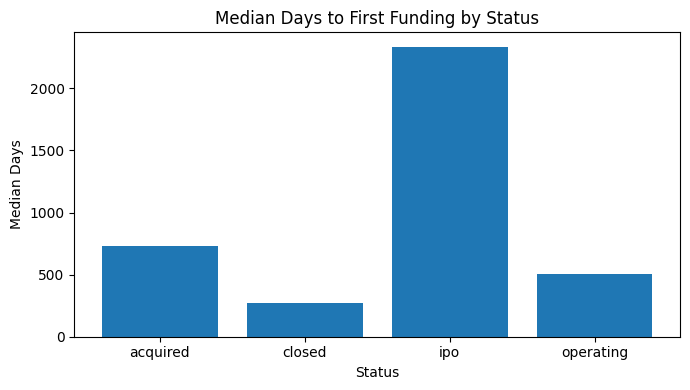

In [83]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(status_funding_summary.index, status_funding_summary['median_days_to_first_funding'])

ax.set_title("Median Days to First Funding by Status")
ax.set_xlabel("Status")
ax.set_ylabel("Median Days")
plt.tight_layout()
plt.show()

### category_list: parsing a multi label field

Each startup can belong to multiple categories, pipe-delimited in a single string
(example "Apps|Games|Mobile"). We split these out to see how many distinct categories
exist and which ones are most common.

In [77]:
categories_exploded = df['category_list'].dropna().str.split('|').explode()

print(f"Distinct categories: {categories_exploded.nunique()}")
top_categories = categories_exploded.value_counts().head(15)
top_categories

Distinct categories: 858


category_list
Software               8768
Mobile                 5557
Biotechnology          4562
E-Commerce             4152
Curated Web            3030
Social Media           2897
Enterprise Software    2694
Advertising            2470
Health Care            2385
Games                  2284
Internet               2071
SaaS                   1989
Education              1968
Health and Wellness    1929
Apps                   1876
Name: count, dtype: int64

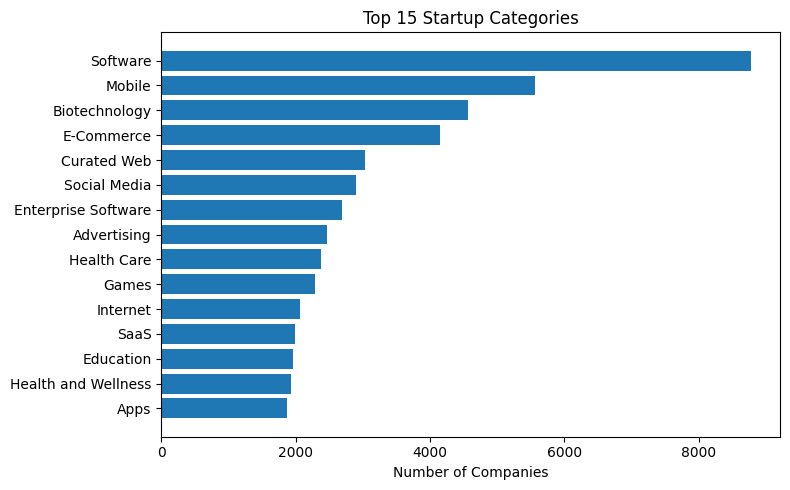

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_categories.index[::-1], top_categories.values[::-1])

ax.set_title("Top 15 Startup Categories")
ax.set_xlabel("Number of Companies")
plt.tight_layout()
plt.show()

### Geography

country_code is ~10% missing. We looked at where the non-missing rows are concentrated,
since a heavy skew toward one country affects how we will handle the missing geography
fields during preprocessing.

In [85]:
top_countries = df['country_code'].value_counts().head(10)
top_countries_pct = (top_countries / len(df) * 100).round(2)

pd.DataFrame({'count': top_countries, 'percent_of_all_rows': top_countries_pct})

,count,percent_of_all_rows
country_code,,
USA,37601,56.66
GBR,3687,5.56
CAN,1925,2.90
IND,1596,2.40
CHN,1544,2.33
FRA,1135,1.71
DEU,1082,1.63
ISR,965,1.45
ESP,746,1.12


### Duplicate records

In the dataset, permalink should uniquely identify a company. We also checked name, since a duplicate
name with a different permalink could be a legitimately different company or a data entry
issue, and that distinction matters for preprocessing.

In [86]:
n_dup_permalinks = df['permalink'].duplicated().sum()
n_dup_names = df['name'].duplicated().sum()

print(f"Duplicate permalinks: {n_dup_permalinks}")
print(f"Duplicate names (different permalinks): {n_dup_names}")

df[df['name'].duplicated(keep=False)].sort_values('name')[['permalink', 'name', 'country_code', 'status']].head(10)

Duplicate permalinks: 0
Duplicate names (different permalinks): 265


,permalink,name,country_code,status
10751,/organization/3divaz-2,3DIVAZ,NaN,closed
10752,/organization/3divaz-3,3DIVAZ,CHE,operating
54327,/organization/aps-llc,APS,USA,operating
51013,/organization/aps,APS,NaN,operating
42534,/organization/apx,APX,NLD,operating
48416,/organization/apx-2,APX,USA,operating
5420,/organization/adtena,Adtena,NaN,operating
5421,/organization/adtena-2,Adtena,NaN,closed
47189,/organization/agora-3,Agora,USA,operating
53958,/organization/agora-6,Agora,USA,operating
